# Jev vs Claude Opus: Zandi ophthalmic set and options-only baseline (v7)

**What this runs** (deviation D6 in the pre-registration):

1. The Zandi et al. 2024 ophthalmic set: 80 complaints (40 diagnoses, each written with 3 and with 5 descriptors), through Jev, Claude Opus 5.5, and Claude Opus 5 with thinking off. About 1,025 calls per model.
2. The options-only baseline for all three datasets: 5 calls per dataset per model with no patient information.
3. Analysis and calibration figures for everything.

**Time: about 3 to 3.5 hours total.** Jev takes about 5 minutes; each Opus model about 90 to 100 minutes (roughly 5 to 6 seconds per call). Progress prints every 25 calls. If Colab disconnects, Runtime > Run all resumes where it stopped.

Secrets needed: `OPENROUTER_API_KEY`, `ANTHROPIC_API_KEY`.

## 1. Setup and code check

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os, sys, shutil, hashlib, json, subprocess, datetime, glob
VERSION = 'v7'
WORK = '/content/drive/MyDrive/jev_bench'
D = f'{WORK}/data'
OUT = f'{WORK}/results.jsonl'
FIG = f'{WORK}/runs/figures'

!pip -q install anthropic
for k in ('OPENROUTER_API_KEY', 'ANTHROPIC_API_KEY'):
    try:
        os.environ[k] = userdata.get(k)
        print(k, 'loaded')
    except Exception as e:
        print(k, 'MISSING:', e)

EXPECTED = {'clients.py': ('v5', '16472190f65fd6ec55e2888b89c8daf9176768a90ac5c191e13ebfb8a79f49d0'), 'ddxplus_to_cases.py': ('v5', '0a2c9072ec480fe52e3eef4f420fcc2f37a71372d252c84a442e34a922912c51'), 'plots.py': ('v6', 'b1b426a07e94fbb615d116c39ff0604d7aa2a9b9d0b8e4b9d0718efeebc35d1c'), 'run.py': ('v7', 'b1a46cc7b071d9603600bb2940079090f09ad11d50062599a9578c3aec87b798'), 'analyze.py': ('v7', 'aa0bf247a4790a4d6c96488f886ae03efa2bf2d31b558ac2513752fcf3944ade')}  # file -> (code folder, sha256)

def sha(path):
    return hashlib.sha256(open(path, 'rb').read()).hexdigest()

RUN = '/content/jev_bench'
os.makedirs(RUN, exist_ok=True)
bad = []
for f, (folder, h) in EXPECTED.items():
    p = f'{WORK}/code/{folder}/{f}'
    if not os.path.exists(p):
        bad.append(f'{folder}/{f}: missing')
    elif sha(p) != h:
        bad.append(f'{folder}/{f}: hash mismatch')
    else:
        shutil.copy(p, f'{RUN}/{f}')
if bad:
    raise SystemExit('Code check FAILED, paste this to Claude:\n' + '\n'.join(bad))
os.chdir(RUN)
sys.path.insert(0, RUN)
print('All', len(EXPECTED), 'files verified for', VERSION)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00
OPENROUTER_API_KEY loaded
ANTHROPIC_API_KEY loaded
All 5 files verified for v7


## 2. Version control

In [2]:
GOOGLE_NATIVE = ('.gsheet', '.gdoc', '.gslides', '.gform', '.gdraw', '.gmap', '.gsite', '.gjam')

def _git(*args):
    return subprocess.run(['git', '-C', WORK, *args], capture_output=True, text=True)

def _safe_sha(p):
    try:
        return sha(p)
    except OSError as e:
        return f'unreadable: {e.strerror}'

def _notebook_json():
    try:
        from google.colab import _message
        return _message.blocking_request('get_ipynb', request='', timeout_sec=30)['ipynb']
    except Exception as e:
        print('  (could not capture notebook contents:', e, ')')
        return None

def snapshot(label):
    stamp = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    os.makedirs(f'{WORK}/runs', exist_ok=True)
    nbj = _notebook_json()
    if nbj:
        json.dump(nbj, open(f'{WORK}/runs/notebook_snapshot.ipynb', 'w'), indent=1)
    manifest = {'label': label, 'utc': stamp, 'version': VERSION,
                'code_sha256': {f'{d}/{f}': h for f, (d, h) in EXPECTED.items()},
                'data_sha256': {os.path.relpath(p, WORK): _safe_sha(p)
                                for p in sorted(glob.glob(f'{D}/**/*', recursive=True))
                                if os.path.isfile(p) and not p.endswith(GOOGLE_NATIVE)},
                'results_sha256': sha(OUT) if os.path.exists(OUT) else None}
    json.dump(manifest, open(f'{WORK}/runs/MANIFEST.json', 'w'), indent=2)
    vdir = f'{WORK}/versions/{stamp}_{label}'
    os.makedirs(vdir, exist_ok=True)
    shutil.copy(f'{WORK}/runs/MANIFEST.json', vdir)
    _git('add', '-A')
    c = _git('commit', '-q', '-m', f'{VERSION} {label} {stamp}')
    head = _git('rev-parse', '--short', 'HEAD').stdout.strip()
    print(f'snapshot "{label}": commit {head}' + ('' if c.returncode == 0 else ' (no changes)'))

snapshot('setup-v7')

snapshot "setup-v7": commit c869f48


## 3. Zandi ophthalmic set (about 3 hours)

One cell per model. Each prints how many calls it will make before starting.

In [3]:
sh = get_ipython().system
Z = f'--cases {D}/zandi_cases.csv --options {D}/zandi_options.json --vague {D}/vague.csv --out {OUT} --max-calls 1200'
snapshot('pre-run-zandi-jev')
sh(f'python run.py --model jev {Z}')

snapshot "pre-run-zandi-jev": commit 203fbf2
1025 jobs to run for jev (1600 already done)
  25/1025
  50/1025
  75/1025
  100/1025
  125/1025
  150/1025
  175/1025
  200/1025
  225/1025
  250/1025
  275/1025
  300/1025
  325/1025
  350/1025
  375/1025
  400/1025
  425/1025
  450/1025
  475/1025
  500/1025
  525/1025
  550/1025
  575/1025
  600/1025
  625/1025
  650/1025
  675/1025
  700/1025
  725/1025
  750/1025
  775/1025
  800/1025
  825/1025
  850/1025
  875/1025
  900/1025
  925/1025
  950/1025
  975/1025
  1000/1025
  1025/1025


In [4]:
snapshot('pre-run-zandi-opus55')
sh(f'python run.py --model opus_verbalized {Z}')

snapshot "pre-run-zandi-opus55": commit 71cadfa
1025 jobs to run for opus_verbalized (1600 already done)
  25/1025
  50/1025
  75/1025
  100/1025
  125/1025
  150/1025
  175/1025
  200/1025
  225/1025
  250/1025
  275/1025
  300/1025
  325/1025
  350/1025
  375/1025
  400/1025
  425/1025
  450/1025
  475/1025
  500/1025
  525/1025
  550/1025
  575/1025
  600/1025
  625/1025
  650/1025
  675/1025
  700/1025
  725/1025
  750/1025
  775/1025
  800/1025
  825/1025
  850/1025
  875/1025
  900/1025
  925/1025
  950/1025
  975/1025
  1000/1025
  1025/1025


In [5]:
snapshot('pre-run-zandi-opus5-nothink')
sh(f'python run.py --model opus5_nothink {Z}')

snapshot "pre-run-zandi-opus5-nothink": commit 063dabb
1025 jobs to run for opus5_nothink (1600 already done)
  25/1025
  50/1025
  75/1025
  100/1025
  125/1025
  150/1025
  175/1025
  200/1025
  225/1025
  250/1025
  275/1025
  300/1025
  325/1025
  350/1025
  375/1025
  400/1025
  425/1025
  450/1025
  475/1025
  500/1025
  525/1025
  550/1025
  575/1025
  600/1025
  625/1025
  650/1025
  675/1025
  700/1025
  725/1025
  750/1025
  775/1025
  800/1025
  825/1025
  850/1025
  875/1025
  900/1025
  925/1025
  950/1025
  975/1025
  1000/1025
  1025/1025


## 4. Options-only baseline on Semigran-45 and DDXPlus (a few minutes)

In [6]:
snapshot('pre-run-options-only')
for m in ('jev', 'opus_verbalized', 'opus5_nothink'):
    sh(f'python run.py --model {m} --cases {D}/cases.csv --options {D}/options.json --out {OUT} --conditions H7 --max-calls 20')
    sh(f'python run.py --model {m} --cases {D}/ddxplus_cases.csv --options {D}/ddxplus_options.json --out {OUT} --conditions H7 --max-calls 20')

snapshot "pre-run-options-only": commit 1662e28
5 jobs to run for jev (2625 already done)
5 jobs to run for jev (2630 already done)
5 jobs to run for opus_verbalized (2625 already done)
5 jobs to run for opus_verbalized (2630 already done)
5 jobs to run for opus5_nothink (2623 already done)
5 jobs to run for opus5_nothink (2628 already done)


## 5. Analysis, figures and final commit

wrote reliability_ddxplus.png and .csv
wrote reliability_semigran45.png and .csv
wrote reliability_zandi80.png and .csv
# Results summary

Harness commit(s): 483889f, 54988ba, 79850b7, 8965c7b, 9ab7e87, b0e1890, ef4e15e, unrecorded
Resolved model versions: jev=typesafe/jev-1.13-20260917, opus5_nothink=claude-opus-5, opus_verbalized=claude-opus-5-5

## Output resolution (Amendment 1, descriptive)

- jev: exact-zero rate 92.0%; values on a 0.01 grid 98.8%; smallest nonzero 0.01 (n=113170)
- opus5_nothink: exact-zero rate 0.0%; values on a 0.01 grid 0.3%; smallest nonzero 0.0001 (n=113092)
- opus_verbalized: exact-zero rate 1.8%; values on a 0.01 grid 3.3%; smallest nonzero 0.0001 (n=113170)

## Token usage (v5, where recorded)

- opus5_nothink: n=2633; thinking tokens median 0 (IQR 0 to 0), share of calls with any thinking 0.0%; output tokens median 679
- opus_verbalized: n=2035; thinking tokens median 0 (IQR 0 to 108), share of calls with any thinking 34.9%; output tokens median 659
- E

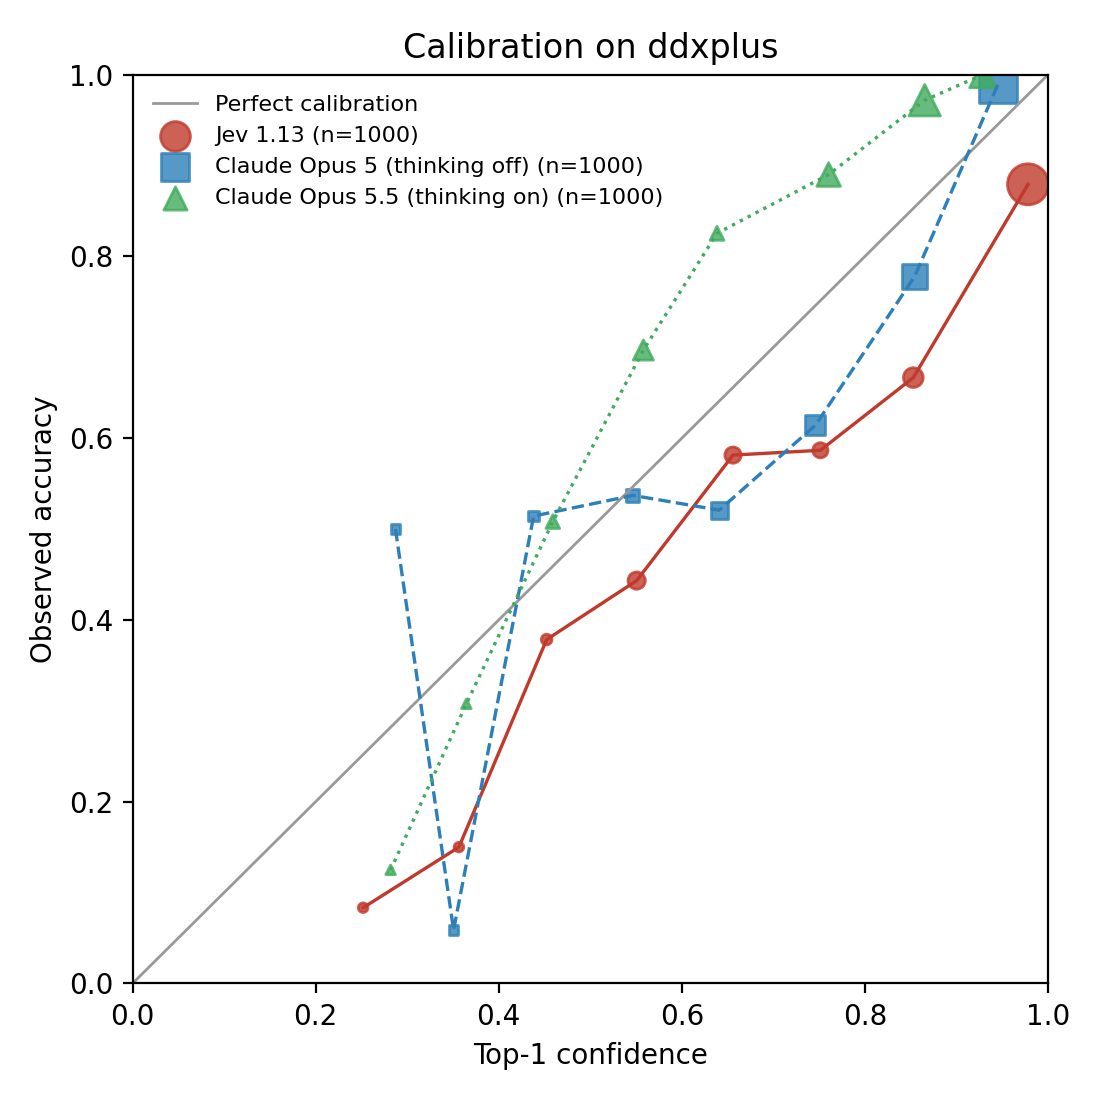

reliability_semigran45.png


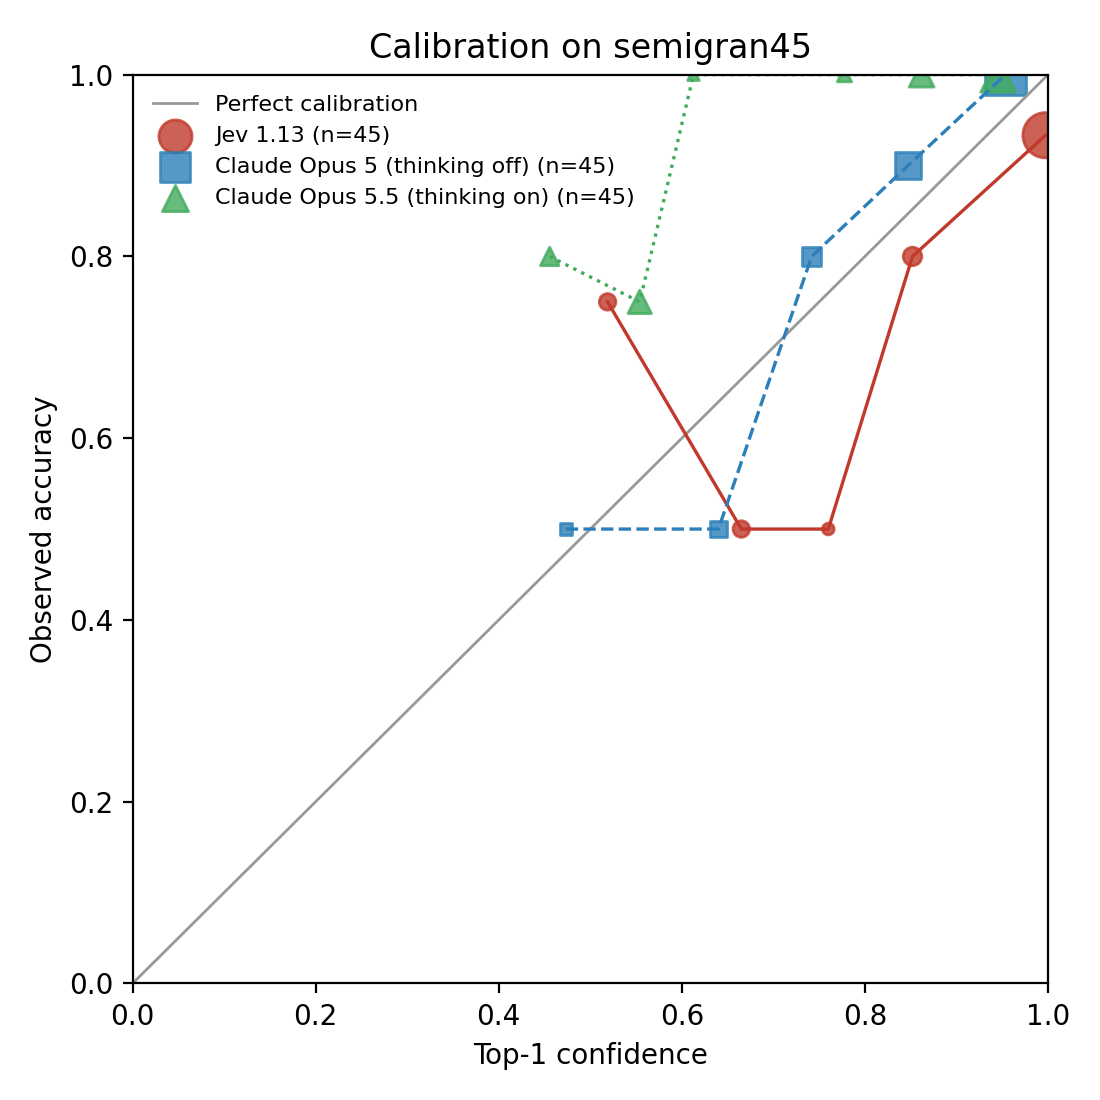

reliability_zandi80.png


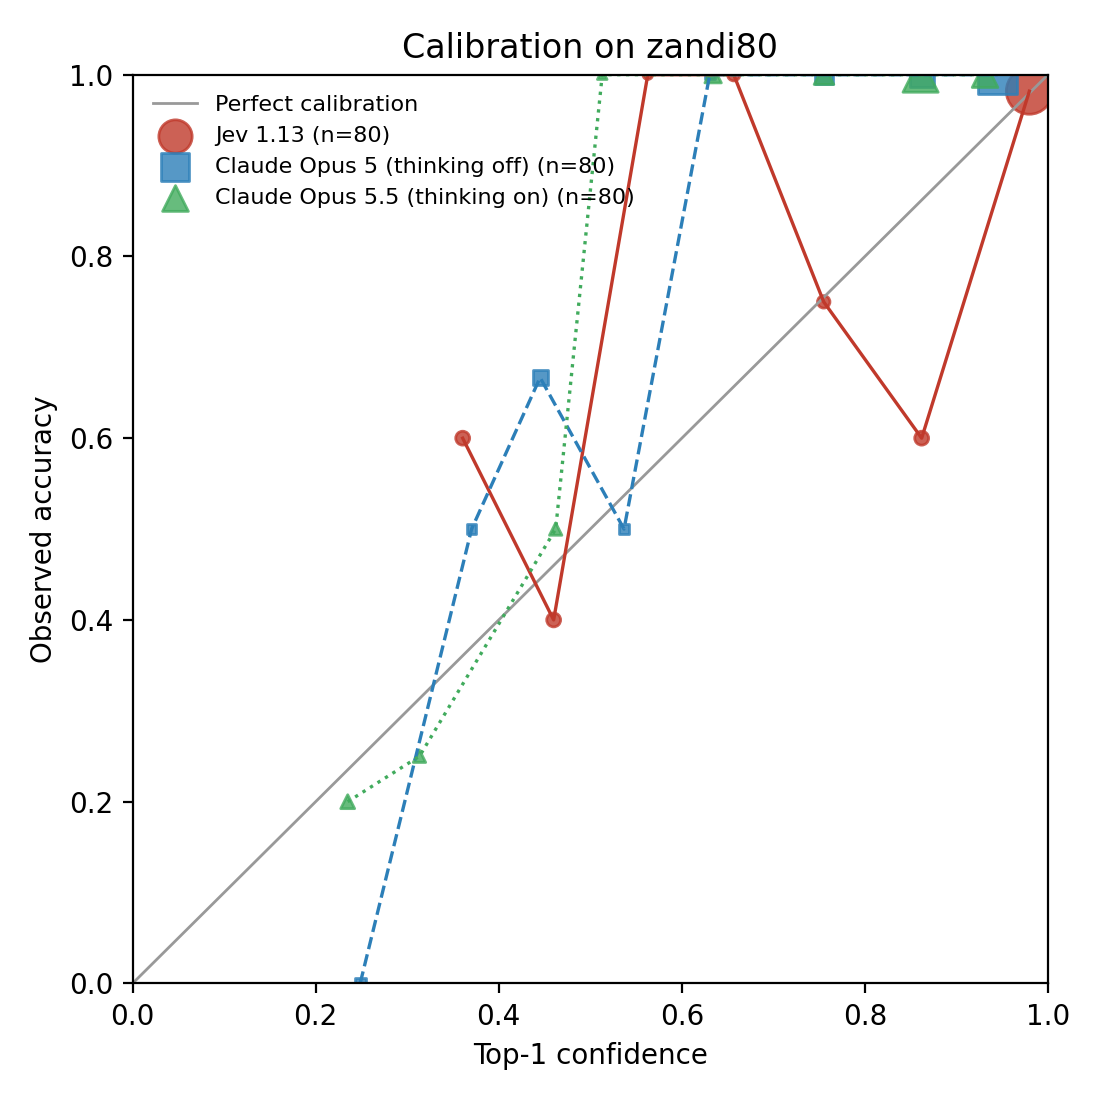

snapshot "analysis-v7": commit 81f8117
81f8117 v7 analysis-v7 20260928T002850Z
1662e28 v7 pre-run-options-only 20260928T002035Z
063dabb v7 pre-run-zandi-opus5-nothink 20260927T223520Z
71cadfa v7 pre-run-zandi-opus55 20260927T204958Z
203fbf2 v7 pre-run-zandi-jev 20260927T204605Z



In [7]:
sh(f'python analyze.py {OUT} --cases {D}/ddxplus_cases.csv > {WORK}/runs/summary.md')
sh(f'python plots.py {OUT} --outdir {FIG}')
print(open(f'{WORK}/runs/summary.md').read())
from IPython.display import Image, display
for p in sorted(glob.glob(f'{FIG}/*.png')):
    print(os.path.basename(p)); display(Image(p, width=450))
snapshot('analysis-v7')
print(_git('log', '--oneline', '-5').stdout)